In [1]:
from utils.custom_plots import (line_plot,
                                bar_plot, 
                                scatter_plot,
                                ecdf_plot,
                                box_plot,
                                distribution_plot,
                                grouped_box_plot)
from utils.db_utils import run_query

import plotly.io as pio
pio.renderers.default = "png"       # drop this two lines to get local interactive plotly charts

<div class="alert alert-block alert-success">

# **Unit economics**
- Unit economics: Measures performance per unit, as opposed to overall performance

- Example: Average Revenue Per User (ARPU)

    - Formula: $\frac{\textit{Revenue}}{\textit{Count of users}}$

    - Use: Measures a company's success in scaling its business model

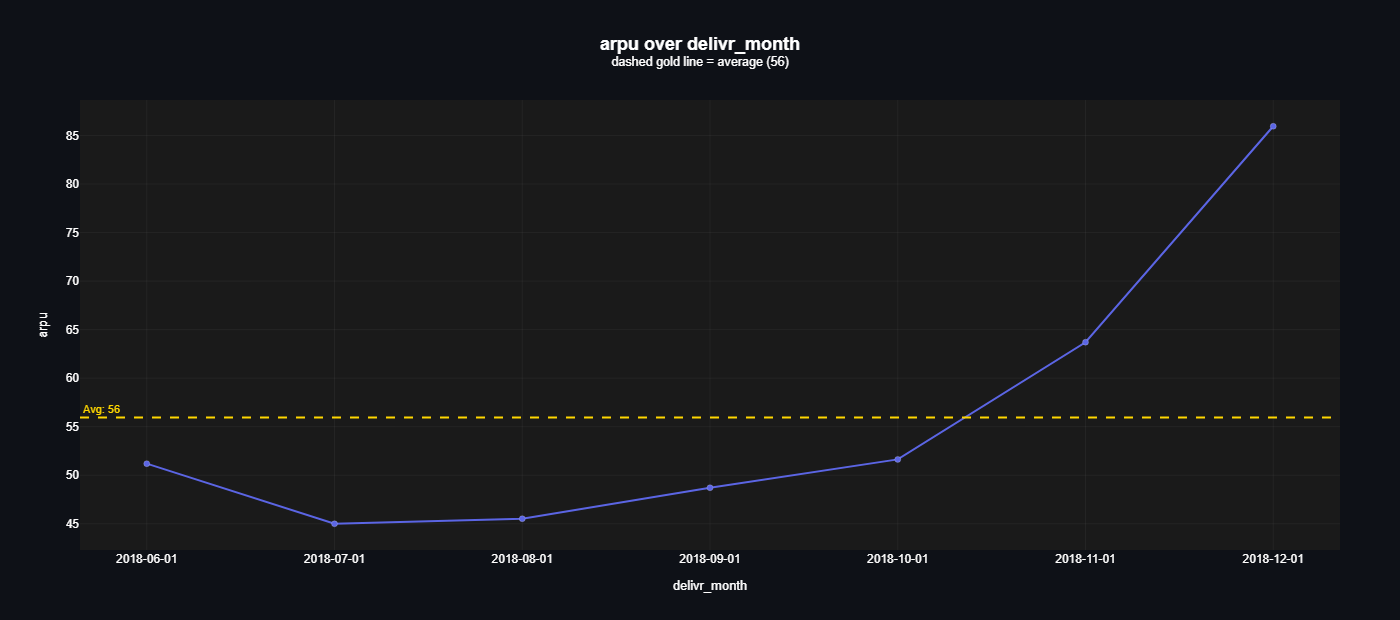

In [ ]:
# MoM average-revenue-per-user query 

MoM_arpu_query = run_query('''
WITH kpis AS (
    SELECT date_trunc('month', order_date)::date AS delivr_month,
           sum(meal_price * order_quantity)      AS revenue,
           count(DISTINCT user_id)               AS users
    FROM orders
        INNER JOIN meals USING (meal_id)
    GROUP BY delivr_month
)
SELECT delivr_month,
       round(revenue::numeric / nullif(users, 0), 2) AS arpu
FROM kpis
ORDER BY delivr_month;
''')

MoM_arpu_lineplot = line_plot(df=MoM_arpu_query,
                              x='delivr_month',
                              y='arpu',
                              avg_line=True)
MoM_arpu_lineplot

# similar pattern to stickiness lineplot

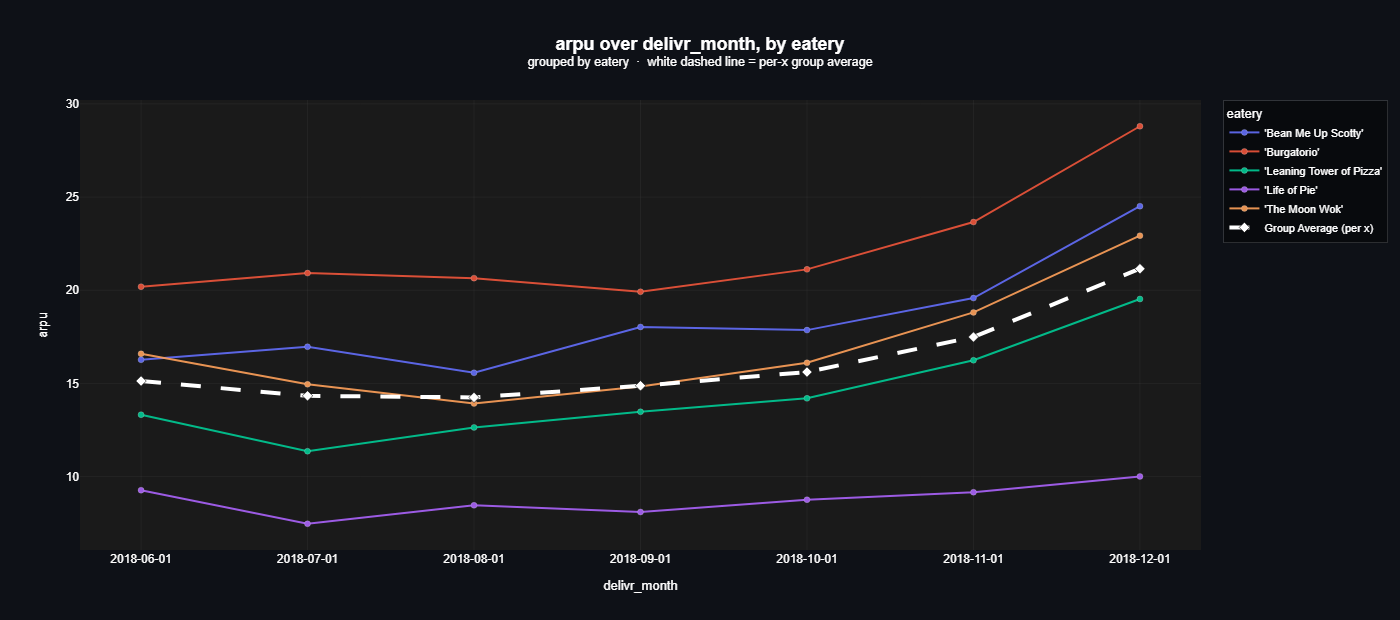

In [3]:
# MoM average-revenue-per-user query grouped per-eatery 

MoM_arpu_pereatery_query = run_query('''
WITH kpis AS (
    SELECT eatery,
           date_trunc('month', order_date)::date AS delivr_month,
           sum(meal_price * order_quantity)      AS revenue,
           count(DISTINCT user_id)               AS users
    FROM orders
        INNER JOIN meals USING (meal_id)
    GROUP BY delivr_month, eatery
)
SELECT delivr_month,
       eatery,
       round(revenue::numeric / nullif(users, 0), 2) AS arpu
FROM kpis
ORDER BY delivr_month;
''')

MoM_arpu_pereatery_lineplot = line_plot(df=MoM_arpu_pereatery_query,
                                        x='delivr_month',
                                        y='arpu',
                                        group_col='eatery',
                                        avg_group_line=True)

MoM_arpu_pereatery_lineplot